# M13 — Latent dynamics, Kalman updates, and what DCM adds

**Original guided lab · 75–100 minutes.** Read 20 min, predict/code 35 min, failure investigation 20 min, explain and transfer 15 min. Run all cells in order in a fresh kernel. All executed data are synthetic unless explicitly stated. No network, GPU, or external dataset is required.

A state-space model separates an evolving latent process from an observation process. The latent state can describe an unobserved signal; the observation model describes how noisy measurements arise from it. In a linear Gaussian model, a transition matrix propagates state and uncertainty, and an observation matrix maps state into measurements. This framework makes the difference between dynamics and measurement explicit.

The Kalman filter combines a predicted state with new evidence. Prediction uses the previous state and the dynamics. The update compares the actual observation with its prediction; the Kalman gain balances uncertainty in the state prediction against measurement noise. The updated covariance expresses remaining uncertainty under the chosen model. If the observation is noisy, the filter should usually trust it less. If the state can change rapidly, an overly rigid transition model can lag behind real changes.

Our scalar example uses an autoregressive latent state and noisy observations. We supply the true parameters and calculate every update directly. This is state estimation under known parameters, not an estimation of brain connectivity. A second filter incorrectly assumes almost noiseless observations. It follows measurement noise more closely and has a worse latent-state reconstruction error in this constructed experiment. Small reported uncertainty under a wrong noise model does not mean the state is actually known precisely.

Filtering is causal in the signal-processing sense that it uses past and current observations; it is not causal inference about biological mechanisms. A lagged predictor can help forecast a measurement while still reflecting common drivers, hemodynamic differences, or unmeasured causes. An estimated transition coefficient is meaningful only in the context of the state and observation model.

Dynamic causal modeling for fMRI adds a scientific generative model linking neuronal dynamics, experimental inputs, and a hemodynamic observation process to BOLD, with model estimation and comparison. It is not ordinary correlation, a generic autoregression, or this Kalman example renamed. The SPM tutorial is included as a reading and supervised extension. No DCM estimation is executed here, and no effective-connectivity claim follows from the scalar simulation.

Ask AI to identify which quantities are fixed, which are learned, which are latent, and which are measured. Specify time units before interpreting transition parameters. If a state model is applied to data resampled at a different TR, unchanged coefficients need not describe the same physical dynamics. Compare residual structure and out-of-sample forecasting, and perform parameter-sensitivity checks rather than trusting an appealing smooth trace. A smooth posterior mean is a model-dependent estimate, not a direct measurement of neuronal activity.

## Transformation contract

Latent transition plus noisy observations → predicted mean/variance → innovation and Kalman gain → updated mean/variance. Filtering reduces observation noise under its assumptions and discards some rapid measurement variation; it does not reveal unique biological causes.

## Ask your AI tutor

```text
Explain this notebook one transformation at a time.
Before each cell ask me to predict shapes, units, and a check.
Give edits in executable cells of at most 20 lines.
Keep the prescribed split, random seed, and tests intact.
Distinguish generated suggestions from executed results.
After the failure experiment, ask me to explain the mechanism.
```

In [1]:
import numpy as np
rng=np.random.default_rng(413)
a,Q,R=.9,.15,1.
x=np.zeros(400)
for t in range(1,len(x)):x[t]=a*x[t-1]+rng.normal(0,np.sqrt(Q))
y=x+rng.normal(0,np.sqrt(R),len(x))
def kalman(observations,measurement_variance):
    mean,var=0.,1.;means=[];variances=[]
    for value in observations:
        predicted=a*mean;prior_var=a*a*var+Q
        gain=prior_var/(prior_var+measurement_variance)
        mean=predicted+gain*(value-predicted);var=(1-gain)*prior_var
        means.append(mean);variances.append(var)
    return np.array(means),np.array(variances)
estimate,uncertainty=kalman(y,R)
bad,bad_uncertainty=kalman(y,.001)
errors=[np.mean((v-x)**2) for v in [y,estimate,bad]]
print('Observed / correct-filter / wrong-noise MSE:',errors)
assert errors[1]<errors[0] and errors[1]<errors[2] and np.all(uncertainty>0)


Observed / correct-filter / wrong-noise MSE: [np.float64(0.971160202761464), np.float64(0.24390892151815385), np.float64(0.9580723999675794)]


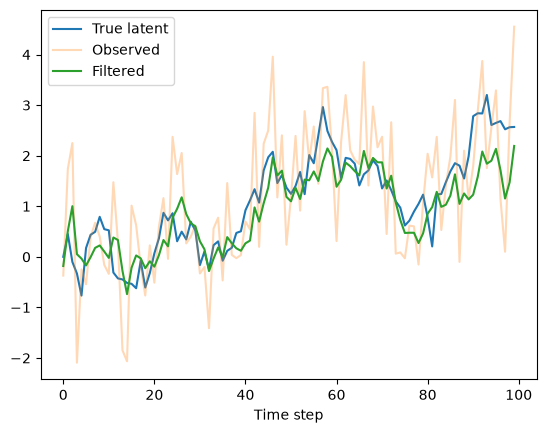

Mean reported variance correct/wrong: 0.26982237619387406 0.0009934264546838912


In [2]:
import matplotlib.pyplot as plt
plt.plot(x[:100],label='True latent');plt.plot(y[:100],alpha=.3,label='Observed')
plt.plot(estimate[:100],label='Filtered');plt.legend();plt.xlabel('Time step');plt.show()
print('Mean reported variance correct/wrong:',uncertainty.mean(),bad_uncertainty.mean())
assert bad_uncertainty.mean()<uncertainty.mean()


## Deliberate failure and repair

The wrong observation-noise assumption gives smaller reported variance but worse recovery of the known latent state. Repair the model using diagnostic evidence rather than treating uncertainty output as self-validating. A second failure would interpret the fitted signal as effective connectivity; this model has only one state and no neuronal/hemodynamic causal architecture.

## Your investigation

Draw separate transition and observation equations and annotate their units. Predict what increasing Q or R does before editing. Read the SPM DCM workflow and list inputs and assumptions absent here. State which claim a forecasting model can support and which additional assumptions a mechanistic interpretation requires.

## Transfer to real neuroimaging

Real latent-state inference requires a justified temporal observation model, missing-sample handling, and parameter estimation. DCM is a separate supervised extension using SPM and an appropriate experimental design; it is neither installed nor run by this notebook.

**Primary teaching sources, pinned where hosted on GitHub:**

- [NMA: linear dynamics](https://github.com/NeuromatchAcademy/course-content/blob/44634e960df7a14cd0bf7398187f2d209d26b0e8/tutorials/W2D3_LinearSystems/student/W2D3_Tutorial1.ipynb)
- [NMA: Kalman filter](https://github.com/NeuromatchAcademy/course-content/blob/44634e960df7a14cd0bf7398187f2d209d26b0e8/tutorials/W3D3_HiddenDynamics/student/W3D3_Tutorial3.ipynb)
- [SPM: DCM for fMRI first level](https://www.fil.ion.ucl.ac.uk/spm/docs/tutorials/dcm/dcm_fmri_first_level/)

Pinned upstream tutorials are a separate assignment; they have **not been executed** by this core lab. They may require data downloads, specialist dependencies, unfinished student cells, and additional compute.

## Exit questions and answer key

1. Does lower posterior variance always mean higher accuracy? **No; misspecified noise assumptions can produce overconfidence.**
2. Is this DCM? **No; it lacks the specified neuronal, input, and hemodynamic generative structure and estimation procedure.**